✅ BASE_DIR   : /Users/pravallikachepuri/customer-churn-prediction
✅ DATA_DIR   : /Users/pravallikachepuri/customer-churn-prediction/data
✅ RESULTS_DIR: /Users/pravallikachepuri/customer-churn-prediction/results
✅ MODELS_DIR : /Users/pravallikachepuri/customer-churn-prediction/models

✅ Model loaded successfully!
📌 X_test shape : (1409, 19)
📌 y_test shape : (1409,)


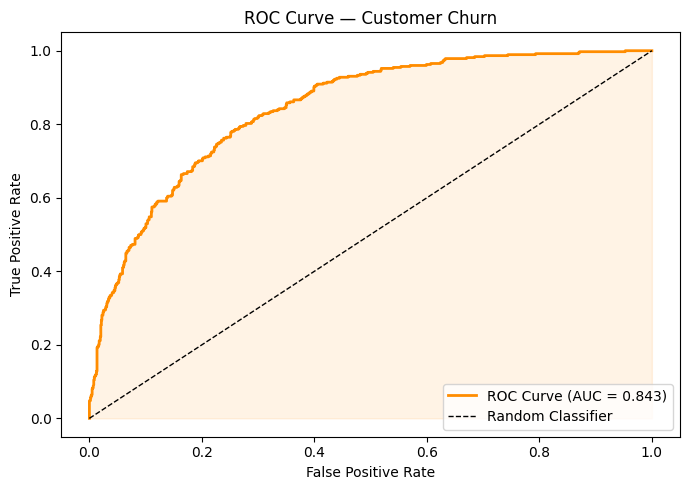

✅ ROC curve saved!


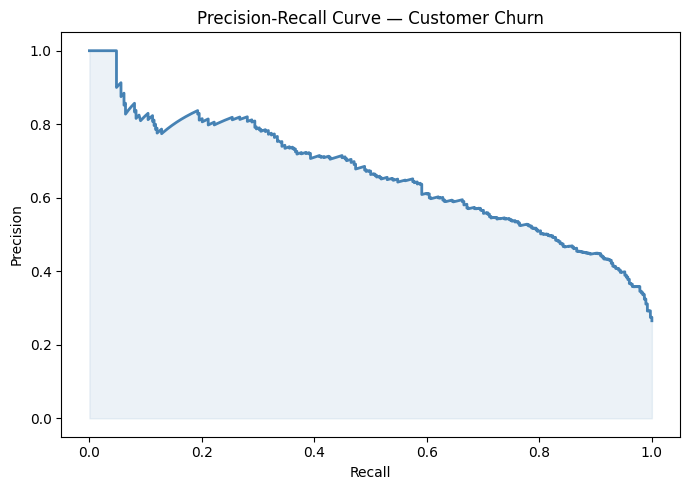

✅ Precision-Recall curve saved!

       📊 FINAL MODEL SUMMARY
  ✅ ROC-AUC Score     : 0.8429
  ✅ Test samples      : 1409
  ✅ Charts saved to   : /Users/pravallikachepuri/customer-churn-prediction/results

🎉 All 4 Notebooks Complete!


In [2]:
# ============================================================
# 📈 NOTEBOOK 4 — Advanced Evaluation (Clean Version)
# ============================================================

import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# ── Setup Paths ──────────────────────────────────────────────
BASE_DIR    = os.path.expanduser('~/customer-churn-prediction')
DATA_DIR    = os.path.join(BASE_DIR, 'data')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')

os.makedirs(RESULTS_DIR, exist_ok=True)

print("✅ BASE_DIR   :", BASE_DIR)
print("✅ DATA_DIR   :", DATA_DIR)
print("✅ RESULTS_DIR:", RESULTS_DIR)
print("✅ MODELS_DIR :", MODELS_DIR)

# ── Load Model ───────────────────────────────────────────────
with open(os.path.join(MODELS_DIR, 'xgb_churn_model.pkl'), 'rb') as f:
    model = pickle.load(f)
print("\n✅ Model loaded successfully!")

# ── Load Test Data ───────────────────────────────────────────
X_test = pd.read_csv(os.path.join(DATA_DIR, 'X_test.csv')).values
y_test = pd.read_csv(os.path.join(DATA_DIR, 'y_test.csv')).values.ravel()
y_prob = model.predict_proba(X_test)[:, 1]

print(f"📌 X_test shape : {X_test.shape}")
print(f"📌 y_test shape : {y_test.shape}")

# ── ROC Curve ────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Customer Churn')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curve.png'))
plt.show()
print("✅ ROC curve saved!")

# ── Precision-Recall Curve ───────────────────────────────────
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='steelblue', lw=2)
plt.fill_between(recall, precision, alpha=0.1, color='steelblue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Customer Churn')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'precision_recall.png'))
plt.show()
print("✅ Precision-Recall curve saved!")

# ── Final Summary ────────────────────────────────────────────
print("\n" + "="*45)
print("       📊 FINAL MODEL SUMMARY")
print("="*45)
print(f"  ✅ ROC-AUC Score     : {roc_auc:.4f}")
print(f"  ✅ Test samples      : {len(y_test)}")
print(f"  ✅ Charts saved to   : {RESULTS_DIR}")
print("="*45)
print("\n🎉 All 4 Notebooks Complete!")